In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv('../data/processed/telco_clean.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (7043, 20)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


## What is RFM Segmentation?

RFM stands for Recency, Frequency, and Monetary Value. It is a proven behavioral segmentation technique used by companies like Amazon, Spotify, and Netflix to group customers based on how they engage with the business.

For the Telco dataset we adapt RFM as follows:
- Recency: Tenure (how long the customer has been with us)
- Frequency: Number of services subscribed (how deeply engaged they are)
- Monetary: Monthly Charges (how much value they bring)

Customers are scored 1-4 on each dimension, then grouped into meaningful business segments.

In [3]:
# Count how many services each customer uses
# This becomes our Frequency score

service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# For MultipleLines and InternetService, map properly first
df['MultipleLines_bin'] = df['MultipleLines'].map(
    {'Yes': 1, 'No': 0, 'No phone service': 0})

df['InternetService_bin'] = df['InternetService'].map(
    {'Fiber optic': 1, 'DSL': 1, 'No': 0})

df['OnlineSecurity_bin'] = df['OnlineSecurity'].map(
    {'Yes': 1, 'No': 0, 'No internet service': 0})

df['OnlineBackup_bin'] = df['OnlineBackup'].map(
    {'Yes': 1, 'No': 0, 'No internet service': 0})

df['DeviceProtection_bin'] = df['DeviceProtection'].map(
    {'Yes': 1, 'No': 0, 'No internet service': 0})

df['TechSupport_bin'] = df['TechSupport'].map(
    {'Yes': 1, 'No': 0, 'No internet service': 0})

df['StreamingTV_bin'] = df['StreamingTV'].map(
    {'Yes': 1, 'No': 0, 'No internet service': 0})

df['StreamingMovies_bin'] = df['StreamingMovies'].map(
    {'Yes': 1, 'No': 0, 'No internet service': 0})

# Total services count
service_bin_cols = ['PhoneService', 'MultipleLines_bin', 'InternetService_bin', 'OnlineSecurity_bin', 'OnlineBackup_bin', 
                    'DeviceProtection_bin', 'TechSupport_bin', 'StreamingTV_bin', 'StreamingMovies_bin']

df['num_services'] = df[service_bin_cols].sum(axis=1)

print(f"Services range: {df['num_services'].min()} to {df['num_services'].max()}")
print(f"\nService count distribution:")
print(df['num_services'].value_counts().sort_index())

Services range: 1 to 9

Service count distribution:
num_services
1    1264
2     859
3     846
4     965
5     922
6     908
7     676
8     395
9     208
Name: count, dtype: int64


In [4]:
# Score each customer 1-4 on each RFM dimension
# 4 = best, 1 = worst

# RECENCY: Higher tenure = better (more loyal)
df['R_score'] = pd.qcut(df['tenure'], q=4, labels=[1, 2, 3, 4])

# FREQUENCY: More services = better (more engaged)
# Using rank to handle duplicate values
df['F_score'] = pd.qcut(df['num_services'].rank(method='first'), 
                         q=4, labels=[1, 2, 3, 4])

# MONETARY: Higher charges = more valuable
df['M_score'] = pd.qcut(df['MonthlyCharges'], q=4, labels=[1, 2, 3, 4])

# Convert to int for calculation
df['R_score'] = df['R_score'].astype(int)
df['F_score'] = df['F_score'].astype(int)
df['M_score'] = df['M_score'].astype(int)

# Combined RFM score (max = 12, min = 3)
df['RFM_score'] = df['R_score'] + df['F_score'] + df['M_score']

print("RFM Score Distribution:")
print(df['RFM_score'].describe().round(2))
print(f"\nScore range: {df['RFM_score'].min()} to {df['RFM_score'].max()}")

RFM Score Distribution:
count    7043.00
mean        7.48
std         2.72
min         3.00
25%         5.00
50%         7.00
75%        10.00
max        12.00
Name: RFM_score, dtype: float64

Score range: 3 to 12


In [5]:
def assign_segment(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal Customers'
    elif score >= 6:
        return 'At Risk'
    else:
        return 'Lost / Inactive'

df['Segment'] = df['RFM_score'].apply(assign_segment)

# Segment summary
segment_summary = df.groupby('Segment').agg(
    customer_count=('Churn', 'count'),
    churn_rate=('Churn', 'mean'),
    avg_tenure=('tenure', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_services=('num_services', 'mean')
).reset_index()

segment_summary['churn_rate_pct'] = (segment_summary['churn_rate'] * 100).round(1)
segment_summary = segment_summary.drop('churn_rate', axis=1)

print(segment_summary.to_string(index=False))

        Segment  customer_count  avg_tenure  avg_monthly_charges  avg_services  churn_rate_pct
        At Risk            1797   25.487479            57.538203      3.218698            32.6
      Champions            1962   55.368502            95.489322      6.916412            19.0
Lost / Inactive            1917   14.114241            31.534950      1.604069            24.7
Loyal Customers            1367   34.015362            76.750475      4.954645            32.0


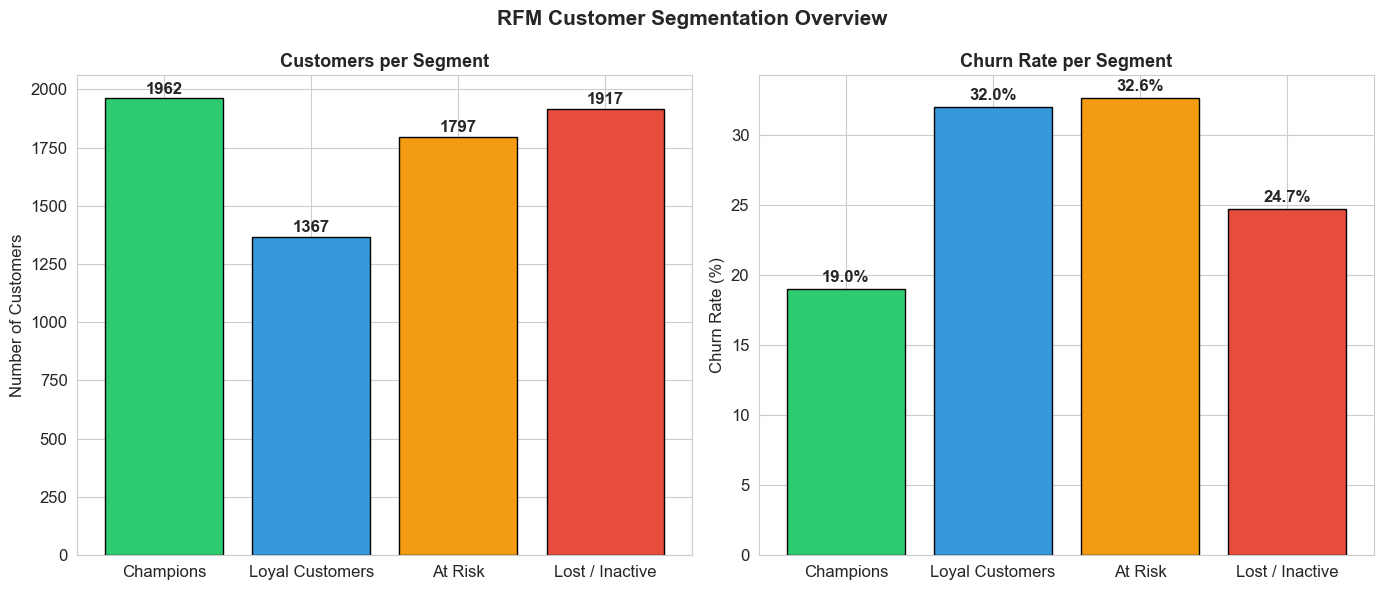

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

segment_order = ['Champions', 'Loyal Customers', 'At Risk', 'Lost / Inactive']
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

# Customer count per segment
counts = [segment_summary[segment_summary['Segment']==s]['customer_count'].values[0] 
          for s in segment_order]

bars = axes[0].bar(segment_order, counts, color=colors, edgecolor='black')
axes[0].set_title('Customers per Segment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(segment_order, rotation=0, ha='center')

for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 str(count), ha='center', fontweight='bold')

# Churn rate per segment
churn_rates = [segment_summary[segment_summary['Segment']==s]['churn_rate_pct'].values[0] 
               for s in segment_order]

bars2 = axes[1].bar(segment_order, churn_rates, color=colors, edgecolor='black')
axes[1].set_title('Churn Rate per Segment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(segment_order, rotation=0, ha='center')

for bar, rate in zip(bars2, churn_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{rate}%', ha='center', fontweight='bold')

plt.suptitle('RFM Customer Segmentation Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

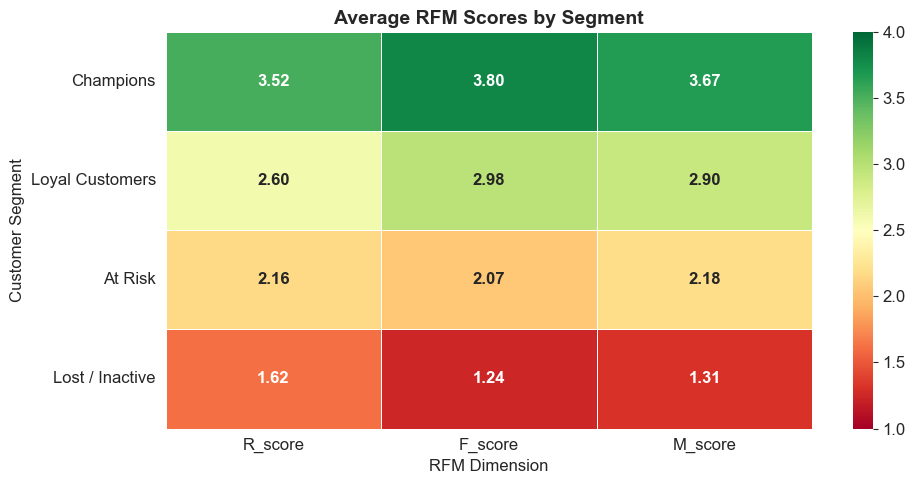

In [12]:
# Average RFM scores per segment
rfm_heatmap = df.groupby('Segment')[['R_score', 'F_score', 'M_score']].mean()
rfm_heatmap = rfm_heatmap.reindex(segment_order)

plt.figure(figsize=(10, 5))
sns.heatmap(rfm_heatmap,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            vmin=1, vmax=4,
            linewidths=0.5,
            annot_kws={'size': 12, 'weight': 'bold'})

plt.title('Average RFM Scores by Segment', fontsize=14, fontweight='bold')
plt.xlabel('RFM Dimension')
plt.ylabel('Customer Segment')
plt.tight_layout()
plt.savefig('../reports/rfm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

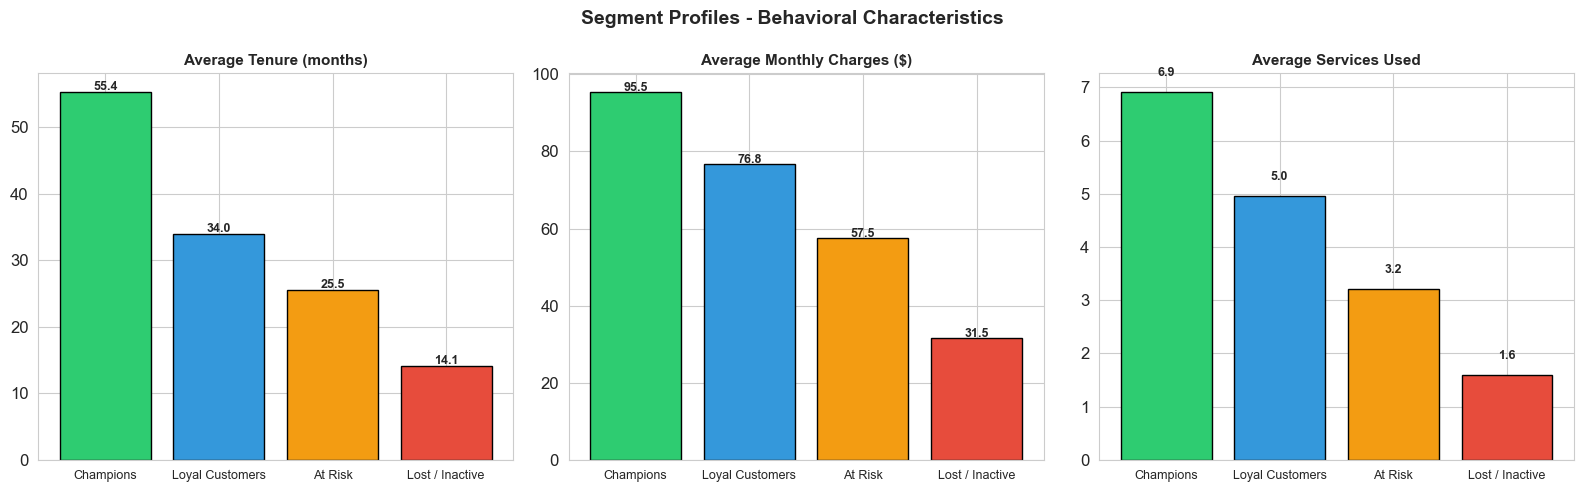

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['avg_tenure', 'avg_monthly_charges', 'avg_services']
titles = ['Average Tenure (months)', 'Average Monthly Charges ($)', 'Average Services Used']

for ax, metric, title in zip(axes, metrics, titles):
    values = [segment_summary[segment_summary['Segment']==s][metric].values[0] 
              for s in segment_order]
    bars = ax.bar(segment_order, values, color=colors, edgecolor='black')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticklabels(segment_order, rotation=0, ha='center', fontsize=9)
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Segment Profiles - Behavioral Characteristics', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/segment_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
df.to_csv('../data/processed/telco_rfm.csv', index=False)

print("Saved: data/processed/telco_rfm.csv")
print(f"\nSegment breakdown:")
print(df['Segment'].value_counts())
print(f"\nNew columns added: R_score, F_score, M_score, RFM_score, Segment, num_services")

Saved: data/processed/telco_rfm.csv

Segment breakdown:
Segment
Champions          1962
Lost / Inactive    1917
At Risk            1797
Loyal Customers    1367
Name: count, dtype: int64

New columns added: R_score, F_score, M_score, RFM_score, Segment, num_services


## Summary - RFM Segmentation Results

| Segment | Description | Key Characteristic |
|---------|-------------|-------------------|
| Champions | Best customers, long tenure, high spend | Protect and reward |
| Loyal Customers | Stable, engaged, moderate risk | Upsell opportunities |
| At Risk | Declining engagement, medium tenure | Send retention offers |
| Lost / Inactive | Low engagement, high churn rate | Low budget priority |

Key insight: At Risk and Lost segments combined account for the majority of churned customers. These are the primary targets for our retention strategy in Notebook 5.

Next: Customer Lifetime Value (CLV) estimation